In [19]:
import random
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [20]:
# Configurando hiperparametros.
args = {
    'batch_size': 32,
    'lr_layer3': 1e-5,
    'lr_layer4': 1e-4,
    'lr_fc': 1e-3,
    'num_epochs': 20,
    'weight_decay': 1e-4,
    'seed': 42
}

# Seed global para reprodutibilidade
random.seed(args['seed'])
np.random.seed(args['seed'])
torch.manual_seed(args['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(args['seed'])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Definindo dispositivo de hardware
if torch.cuda.is_available():
    args['device'] = torch.device('cuda')
else:
    args['device'] = torch.device('cpu')

print(args['device'])
print(f"Seed global: {args['seed']}")

cuda
Seed global: 42


In [21]:
data_transform_treino = transforms.Compose([
                                    transforms.RandomHorizontalFlip(p=0.5),
                                    transforms.RandomRotation(10),
                                    transforms.Resize(224),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                          std=[0.229, 0.224, 0.225])
                  ])

data_transform = transforms.Compose([
                                     transforms.Resize(224),
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                          std=[0.229, 0.224, 0.225])
                  ])

train_set_aug = datasets.ImageFolder(root='../data/fer2013/train', transform=data_transform_treino)
train_set_eval = datasets.ImageFolder(root='../data/fer2013/train', transform=data_transform)
test_set = datasets.ImageFolder(root='../data/fer2013/test', transform=data_transform)

# Split simples e reprodutivel: 90% treino, 10% validacao
split_generator = torch.Generator().manual_seed(args['seed'])
indices = torch.randperm(len(train_set_aug), generator=split_generator).tolist()
val_size = int(0.1 * len(train_set_aug))
val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_set = torch.utils.data.Subset(train_set_aug, train_indices)
val_set = torch.utils.data.Subset(train_set_eval, val_indices)

class_names = train_set_aug.classes
class_to_idx = train_set_aug.class_to_idx

In [22]:
print(f"Imagens de treino: {len(train_set)}")
print(f"Imagens de validacao: {len(val_set)}")
print(f"Classes encontradas: {class_to_idx}")

Imagens de treino: 25839
Imagens de validacao: 2870
Classes encontradas: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.0648367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.0822659].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6212862..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2914162].
Clippin

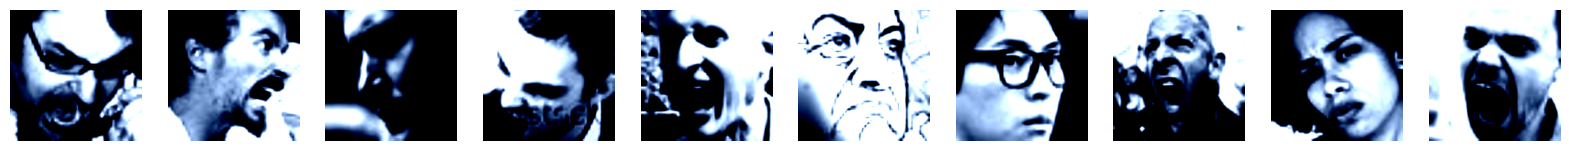

In [23]:
fig, axs = plt.subplots(1,10, figsize=(20, 2))
for i in range(10):
  data, label = test_set[i]
  axs[i].imshow(data.permute((1,2,0)))
  axs[i].axis('off')

In [24]:
train_loader = DataLoader(train_set, 
                          batch_size=args['batch_size'], 
                          shuffle=True)

val_loader = DataLoader(val_set,
                        batch_size=args['batch_size'],
                        shuffle=False)

test_loader = DataLoader(test_set, 
                         batch_size=args['batch_size'], 
                         shuffle=False)

In [25]:
# Pegando apenas um batch de dados
imagens, rotulos = next(iter(train_loader))

print(f"Formato do lote de imagens: {imagens.shape}")
print(f"Formato do lote de rótulos: {rotulos.shape}")
print(f"Primeiro rótulo do lote: {rotulos[0]}")

Formato do lote de imagens: torch.Size([32, 3, 224, 224])
Formato do lote de rótulos: torch.Size([32])
Primeiro rótulo do lote: 3


In [26]:
import torchvision.models as models
import torch.nn as nn

# 1. Reset Total: ResNet18 da fábrica
net = models.resnet18(weights='DEFAULT')

# 2. Congela Tudo (Tranca a casa inteira)
for param in net.parameters():
    param.requires_grad = False

# 3. Descongela cirurgicamente Layer3 e Layer4
for param in net.layer3.parameters():
    param.requires_grad = True
for param in net.layer4.parameters():
    param.requires_grad = True

# 4. Cirurgia da Camada Final
num_features_in = net.fc.in_features
novo_features_out = 7
net.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features_in, novo_features_out)
)

# 5. Manda para a Placa de Vídeo
net = net.to(args['device'])

print(net)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [27]:
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight

rotulos_treino = [train_set_aug.targets[i] for i in train_indices]
pesos_numpy = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(rotulos_treino),
    y=rotulos_treino
)
pesos_tensor = torch.tensor(pesos_numpy, dtype=torch.float).to(args['device'])

criterion = nn.CrossEntropyLoss(weight=pesos_tensor)

optimizer = optim.Adam([
    {'params': net.layer3.parameters(), 'lr': args['lr_layer3']},
    {'params': net.layer4.parameters(), 'lr': args['lr_layer4']},
    {'params': net.fc.parameters(), 'lr': args['lr_fc']}
], weight_decay=args['weight_decay'])

print("Pesos aplicados para cada emocao (em ordem):")
for classe, peso in zip(class_names, pesos_tensor):
    print(f"{classe}: {peso:.4f}")

Pesos aplicados para cada emocao (em ordem):
angry: 1.0217
disgust: 9.4892
fear: 1.0042
happy: 0.5689
neutral: 0.8203
sad: 0.8537
surprise: 1.2956


In [28]:
from sklearn.metrics import accuracy_score

def train(net, criterion, optimizer, train_loader, device):
    net.train()
    epoch_train_loss = []
    pred_list, rotulo_list = [], []
    
    for dado, rotulo in train_loader:
        dado, rotulo = dado.to(device), rotulo.to(device)
        
        ypred = net(dado)
        loss = criterion(ypred, rotulo)
        epoch_train_loss.append(loss.item())
        
        _, pred = torch.max(ypred, axis=1)
        pred_list.extend(pred.cpu().numpy())
        rotulo_list.extend(rotulo.cpu().numpy())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

    train_acc = accuracy_score(rotulo_list, pred_list)
    train_loss = np.mean(epoch_train_loss)

    return train_acc, train_loss

In [29]:
def validate(net, criterion, test_loader, device):
    net.eval()
    epoch_test_loss = []
    pred_list, rotulo_list = [], []

    with torch.no_grad():
        for dado, rotulo in test_loader:
            dado, rotulo = dado.to(device), rotulo.to(device)

            ypred = net(dado)
            loss = criterion(ypred, rotulo)
            epoch_test_loss.append(loss.item())
            
            _, pred = torch.max(ypred, axis=1)
            pred_list.extend(pred.cpu().numpy())
            rotulo_list.extend(rotulo.cpu().numpy())

    test_acc = accuracy_score(rotulo_list, pred_list)
    test_loss = np.mean(epoch_test_loss)

    return test_acc, test_loss

In [30]:
import time

nome_experimento = "resnet18_l3_l4_diff_lr"
caminho_salvamento = f"melhor_modelo_{nome_experimento}.pth"

all_epoch_train_loss = []
all_epoch_train_acc = []
all_epoch_val_loss = []
all_epoch_val_acc = []

best_val_loss = float('inf')

print(f"Iniciando o treinamento por {args['num_epochs']} epocas...\n")

for epoch in range(args['num_epochs']):
    start_time = time.time()

    treino_acc, treino_loss = train(net, criterion, optimizer, train_loader, args['device'])
    val_acc, val_loss = validate(net, criterion, val_loader, args['device'])

    end_time = time.time()
    tempo_total = end_time - start_time

    all_epoch_train_loss.append(treino_loss)
    all_epoch_train_acc.append(treino_acc)
    all_epoch_val_loss.append(val_loss)
    all_epoch_val_acc.append(val_acc)

    print(f"Epoca {epoch+1}/{args['num_epochs']} | Tempo: {tempo_total:.0f}s")
    print(f"Treino - Loss: {treino_loss:.4f} | Acc: {treino_acc*100:.2f}%")
    print(f"Val    - Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}%\n")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(net.state_dict(), caminho_salvamento)
        print(f"[NOVO RECORDE] Val loss caiu para {best_val_loss:.4f}! Arquivo '{caminho_salvamento}' atualizado.")

print("Treinamento finalizado. Avalie o test_loader apenas no fim.")

Iniciando o treinamento por 20 epocas...

Epoca 1/20 | Tempo: 63s
Treino - Loss: 1.5470 | Acc: 42.54%
Val    - Loss: 1.2487 | Acc: 51.99%

[NOVO RECORDE] Val loss caiu para 1.2487! Arquivo 'melhor_modelo_resnet18_l3_l4_diff_lr.pth' atualizado.
Epoca 2/20 | Tempo: 63s
Treino - Loss: 1.2550 | Acc: 53.28%
Val    - Loss: 1.1295 | Acc: 58.61%

[NOVO RECORDE] Val loss caiu para 1.1295! Arquivo 'melhor_modelo_resnet18_l3_l4_diff_lr.pth' atualizado.
Epoca 3/20 | Tempo: 64s
Treino - Loss: 1.1482 | Acc: 56.57%
Val    - Loss: 1.0892 | Acc: 59.41%

[NOVO RECORDE] Val loss caiu para 1.0892! Arquivo 'melhor_modelo_resnet18_l3_l4_diff_lr.pth' atualizado.
Epoca 4/20 | Tempo: 66s
Treino - Loss: 1.0487 | Acc: 59.82%
Val    - Loss: 1.0968 | Acc: 61.15%

Epoca 5/20 | Tempo: 67s
Treino - Loss: 0.9929 | Acc: 61.96%
Val    - Loss: 1.0734 | Acc: 62.26%

[NOVO RECORDE] Val loss caiu para 1.0734! Arquivo 'melhor_modelo_resnet18_l3_l4_diff_lr.pth' atualizado.
Epoca 6/20 | Tempo: 68s
Treino - Loss: 0.9122 | Acc: 

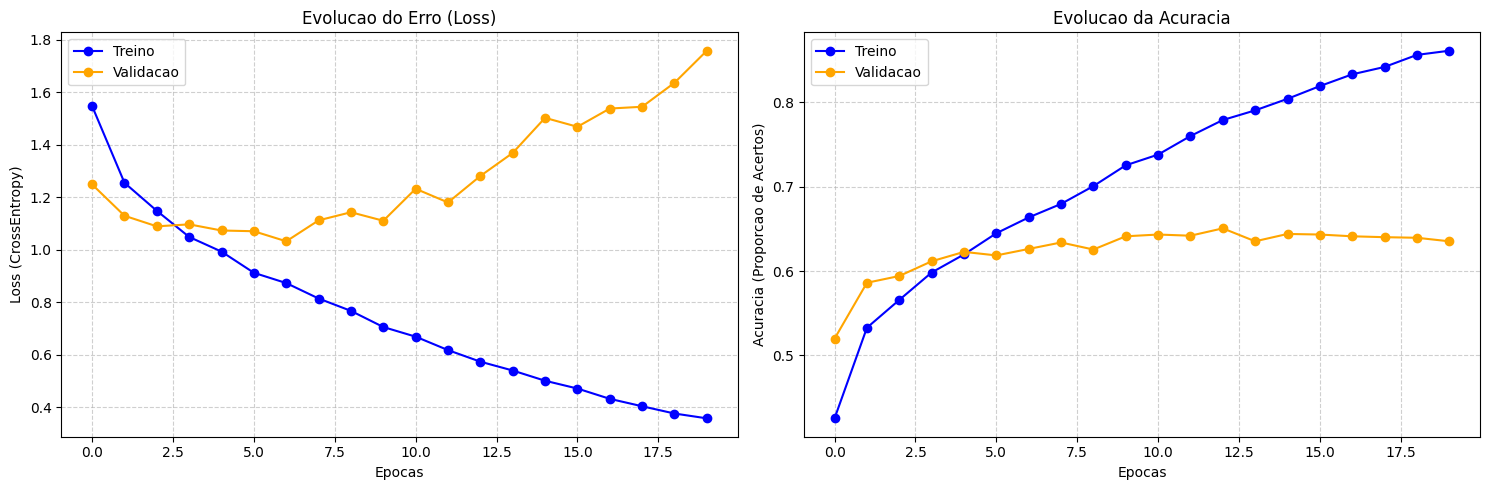

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(all_epoch_train_loss, label='Treino', color='blue', marker='o')
axs[0].plot(all_epoch_val_loss, label='Validacao', color='orange', marker='o')

axs[0].set_title('Evolucao do Erro (Loss)')
axs[0].set_xlabel('Epocas')
axs[0].set_ylabel('Loss (CrossEntropy)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

axs[1].plot(all_epoch_train_acc, label='Treino', color='blue', marker='o')
axs[1].plot(all_epoch_val_acc, label='Validacao', color='orange', marker='o')

axs[1].set_title('Evolucao da Acuracia')
axs[1].set_xlabel('Epocas')
axs[1].set_ylabel('Acuracia (Proporcao de Acertos)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

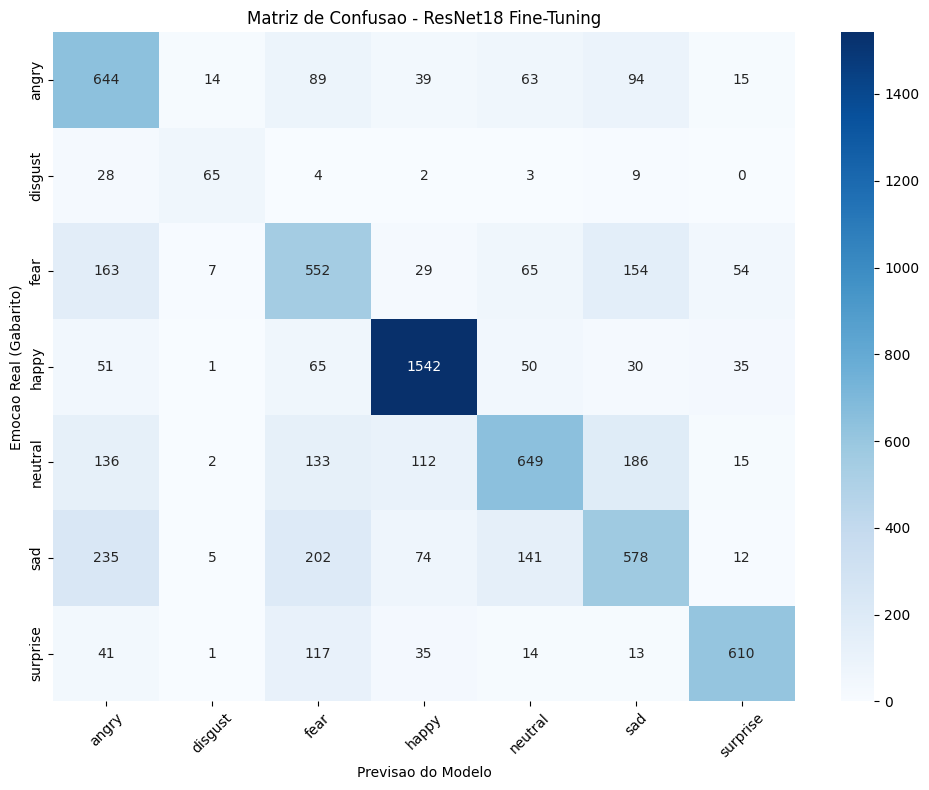

In [32]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

nome_das_classes = class_names

y_real = []
y_pred = []

net.eval()

with torch.no_grad():
    for dado, rotulo in test_loader:
        dado = dado.to(args['device'])

        saida = net(dado)

        _, previsao = torch.max(saida, axis=1)

        y_pred.extend(previsao.cpu().numpy())
        y_real.extend(rotulo.numpy())

matriz = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(matriz, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=nome_das_classes,
            yticklabels=nome_das_classes)
plt.title('Matriz de Confusao - ResNet18 Fine-Tuning')
plt.ylabel('Emocao Real (Gabarito)')
plt.xlabel('Previsao do Modelo')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()